# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [2]:
#config
from pathlib import Path
import os
import zipfile
import urllib.request

if not os.path.exists("../data"):
    os.makedirs("../data")

# check if the dataset.zip is existed, if not, download the data
if not os.path.exists("../data/bank+marketing.zip"):
    print("Downloading dataset...")
    url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
    urllib.request.urlretrieve(url, "../data/bank+marketing.zip")

# Only unzip bank-additional.zip from the container zip
if not os.path.exists("../data/raw/bank-additional"):
    # Extract only bank-additional.zip from the main zip file
    with zipfile.ZipFile("../data/bank+marketing.zip", "r") as zip_ref:
        zip_ref.extract("bank-additional.zip", "../data")

    # Then extract the contents of bank-additional.zip
    with zipfile.ZipFile("../data/bank-additional.zip", "r") as zip_ref:
        zip_ref.extractall("../data/raw")

# Load Data

In [2]:
data = pd.read_csv(
    r'../data/raw/bank-additional/bank-additional-full.csv',
    sep=';'
)
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Model Development

## Model Selection
We decided to train three model with **_starting with simple and add complexity if needed_** strategy so here is list of 3 models we focoused on:

- Logistic Rgression(Baseline): however given that non of the dataset features showed us a linearrlu seperatable, it would not have a promissing results.

- Decision Tree

- Randorm Forrest

- XGBoost Gradient

## Training and Evaluation 

We structured a reproducible, well-orgnized training structure:

1. Preprocess the data with **_columntransformer_** based on unique model requirements
2. Modeling pipeline where we later integrated the fine-tuned paramaters in it.
3. Fine-tuning the model using the **_best params_** outpoted from RandomizedSearchCV.
4. Model evaluation based on accuracy metrices and confusion matrics.


## Model analysis and feature engineering

It worth mentioning that we did not rely on performance metrices and went beyond accuracy. Therefore we focoused on: 

- Model explainability to make our model more of transparent clear approach rather than a black box
- Analyze the permormance metrices given the stakeholder priorities.
- Keep a balance between model complexity, computational cost and our business motivation.



In [3]:
# Drop leakage-prone feature
if "duration" in data.columns:
    X = data.drop(columns=["duration"])

X = X.drop(columns=['y'])
y = data['y']


In [10]:
#clean the pdays as 999 mean never called the person
X['pdays_clean'] = X['pdays'].replace(999,0)
X['contacted_before'] = (X['pdays'] != 999).astype(int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               41188 non-null  int64  
 1   job               41188 non-null  object 
 2   marital           41188 non-null  object 
 3   education         41188 non-null  object 
 4   default           41188 non-null  object 
 5   housing           41188 non-null  object 
 6   loan              41188 non-null  object 
 7   contact           41188 non-null  object 
 8   month             41188 non-null  object 
 9   day_of_week       41188 non-null  object 
 10  campaign          41188 non-null  int64  
 11  pdays             41188 non-null  int64  
 12  previous          41188 non-null  int64  
 13  poutcome          41188 non-null  object 
 14  emp.var.rate      41188 non-null  float64
 15  cons.price.idx    41188 non-null  float64
 16  cons.conf.idx     41188 non-null  float6

In [4]:
#clean the pdays as 999 mean never called the person
X['pdays_clean'] = X['pdays'].replace(999,0)
X['contacted_before'] = (X['pdays'] != 999).astype(int)

#predictor categories
numeric_features = [
    'age',
    'campaign',
    'pdays_clean',
    'previous',
    'contacted_before',
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

categorical_features = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'day_of_week',
    'poutcome'
]

#preprocess for Random forrest 
preprocess1 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

**Caveat** : We setup the parameter n_job = -1 which speed up the training but may slow-down or freez other applications in coputer. 

In [5]:
# -------------------------------------------------------
# Random Forrest Modeling Pipeline 
# -------------------------------------------------------
pipe = Pipeline([
    ('preprocess', preprocess1),
    ('model', RandomForestClassifier(
        random_state=42,
        #penalize missing the minority class
        class_weight='balanced',   # <-- imbalance handling integrated here
        n_estimators= 500,
        max_depth= 10,
        min_samples_leaf= 4,
        n_jobs= -1 #use all the cores in parallel and speed up the training

    ))
])


In [6]:
# -------------------------------------------------------
# Train/test split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, 
    #preserve the subscription rate in both datasets. important while dataset/conversion is imbalanced.
    stratify=y
)


In [9]:
pipe.fit(X_train, y_train )

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome']),
                                                 ('num', 'passthrough',
                                                  ['age', 'campaign',
                                                   'pdays_clean', 'previous',
                                                   'contacted_before',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=4, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

# Hyper parameter tuning:

It will select the best set of parameters for the model. After we identify the parameters, we can feed it into the model pipeline and it make the training time way much more efficient as it will not search the best parameters everytime.

In [ ]:
'''# -------------------------------------------------------
# Hyperparameter tuning
# -------------------------------------------------------
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__class_weight': ['balanced', 'balanced_subsample']  # tune imbalance strategy
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV score:", search.best_score_)

best_pipe = search.best_estimator_'''


Best parameters: {'model__n_estimators': 500, 'model__min_samples_leaf': 4, 'model__max_depth': 10, 'model__class_weight': 'balanced'}
Best CV score: 0.7976551900660848


In [10]:
# -------------------------------------------------------
# Predictions + Probabilities
# -------------------------------------------------------
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

Test ROC AUC: 0.8139544465540827

Confusion Matrix:
 [[6490  820]
 [ 339  589]]

Classification Report:
               precision    recall  f1-score   support

          no       0.95      0.89      0.92      7310
         yes       0.42      0.63      0.50       928

    accuracy                           0.86      8238
   macro avg       0.68      0.76      0.71      8238
weighted avg       0.89      0.86      0.87      8238



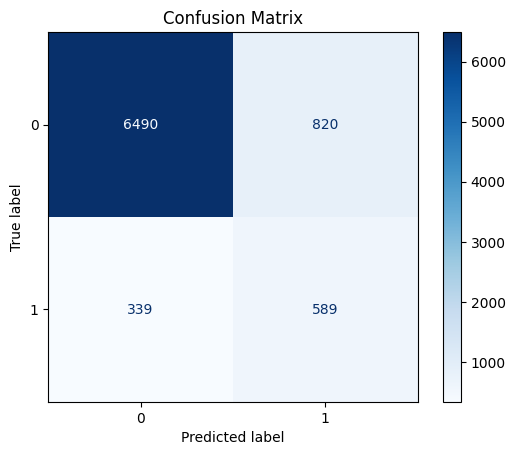

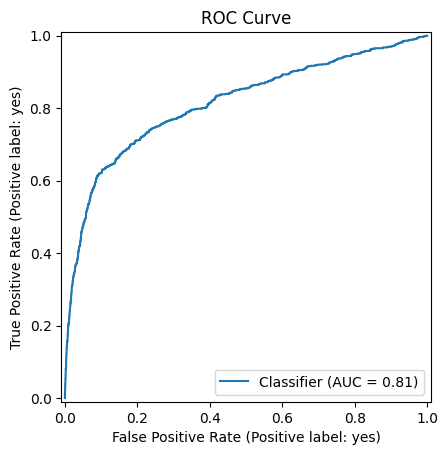

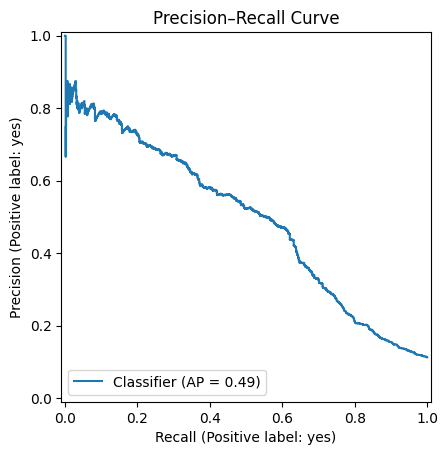

In [13]:
# -------------------------------------------------------
# Evaluation Metrics
# -------------------------------------------------------
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------------------------------
# Confusion Matrix Plot
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# -------------------------------------------------------
# ROC Curve
# -------------------------------------------------------
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    pos_label="yes"
)
plt.title("ROC Curve")
plt.show()

# -------------------------------------------------------
# Precision–Recall Curve
# -------------------------------------------------------
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    pos_label="yes"
)
plt.title("Precision–Recall Curve")
plt.show()


Here we compare model performance in training versus testing checking for overfitting underfitting

In [14]:
# -------------------------------------------------------
# Training Performance (Overfitting Check)
# -------------------------------------------------------

y_train_pred = pipe.predict(X_train)
y_train_proba = pipe.predict_proba(X_train)[:, 1]

print("Train ROC AUC:", roc_auc_score(y_train, y_train_proba))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nTrain Classification Report:\n", classification_report(y_train, y_train_pred))
print("\nTest Classification Report:\n", classification_report(y_test, y_pred))

Train ROC AUC: 0.8453412667752287
Test ROC AUC: 0.8139544465540827

Train Classification Report:
               precision    recall  f1-score   support

          no       0.95      0.89      0.92     29238
         yes       0.41      0.62      0.49      3712

    accuracy                           0.86     32950
   macro avg       0.68      0.75      0.71     32950
weighted avg       0.89      0.86      0.87     32950


Test Classification Report:
               precision    recall  f1-score   support

          no       0.95      0.89      0.92      7310
         yes       0.42      0.63      0.50       928

    accuracy                           0.86      8238
   macro avg       0.68      0.76      0.71      8238
weighted avg       0.89      0.86      0.87      8238



## Model Behavior Analysis

- Comparison results shows model have a stable behavior over train and test set not any overfitting, underfitting detecetd.
- The most pricy error in model is False Negatives (FN) as it is ignoring potential costumers. However our Random forrest model with the best parameters selection after the fine-tuning is showing the improved rate and lower number of FN meaning we successfuly reduced the price of missing potential costumers.
- to check model roboustness and fairness we are considering feature importance and then we will analyze if dataset has captured enough number of important costumers. forexample, if model shows job play crucial role in term deposit decision, and admin jobs have the highest rate of subscription, is the result due to high number of contact with this specific job or it is actual potential costumers.Additionally in data analysis we relied on ratio than frequency making sure our comparison point is normalized.

In [15]:

# -------------------------------------------------------
# Feature Importances
# -------------------------------------------------------
ohe = pipe.named_steps['preprocess'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out()
num_features = X.select_dtypes(exclude='object').columns
all_features = np.concatenate([cat_features, num_features])

importances = pipe.named_steps['model'].feature_importances_

feature_ranking = (
    pd.DataFrame({'feature': all_features, 'importance': importances})
      .sort_values('importance', ascending=False)
)

# Plot top features
top_n = 20
top_features = feature_ranking.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.show()

ValueError: All arrays must be of the same length